# Laporan Praktikum Kecerdasan Buatan

| | |
|---|---|
| Nama | Laura Aurelia |
| NIM | 42324027 |
| Program Studi | D3 Teknologi Informasi |
| Week/Sesi | 5 / 3 |
| Topik | Hierarchical Clustering |
| Tanggal | 06 Oktober 2026 |

## 1. Pendahuluan

Hierarchical Clustering adalah metode klasterisasi yang mengelompokkan data ke dalam bentuk hierarki, yaitu dengan menggabungkan (agglomerative) atau memisahkan klaster secara bertahap. Hasilnya divisualisasikan dalam bentuk dendrogram.

Pada praktikum ini, saya mengerjakan tugas yang diminta modul, yaitu membandingkan dendrogram single linkage dengan complete linkage dan average linkage pada dataset sederhana (percobaan pertama).

Ketiga metode linkage berbeda dalam cara mengukur jarak antar klaster:

- Single linkage: jarak antar klaster = jarak terdekat antara dua titik dari klaster yang berbeda.
- Complete linkage: jarak antar klaster = jarak terjauh antara dua titik dari klaster yang berbeda.
- Average linkage: jarak antar klaster = rata-rata jarak seluruh pasangan titik dari klaster yang berbeda.

## 2. Percobaan 1: Dataset Sederhana

Berikut dataset sederhana (6 titik, 2 fitur) beserta *distance matrix* Euclidean sesuai modul.

In [1]:
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt

# 1. Dataset sederhana
data = np.array([
    [1.0, 1.0],  # a
    [1.5, 1.5],  # b
    [5.0, 5.0],  # c
    [3.0, 4.0],  # d
    [4.0, 4.0],  # e
    [3.0, 3.5]   # f
])
labels = ['a', 'b', 'c', 'd', 'e', 'f']

# 2. Hitung Distance Matrix (Euclidean Distance)
distance_matrix = pdist(data, metric='euclidean')
distance_df = pd.DataFrame(squareform(distance_matrix),
                           columns=labels,
                           index=labels)

# 3. Tampilkan Distance Matrix
print("=== Distance Matrix (Euclidean) ===")
print(distance_df)

=== Distance Matrix (Euclidean) ===
          a         b         c         d         e         f
a  0.000000  0.707107  5.656854  3.605551  4.242641  3.201562
b  0.707107  0.000000  4.949747  2.915476  3.535534  2.500000
c  5.656854  4.949747  0.000000  2.236068  1.414214  2.500000
d  3.605551  2.915476  2.236068  0.000000  1.000000  0.500000
e  4.242641  3.535534  1.414214  1.000000  0.000000  1.118034
f  3.201562  2.500000  2.500000  0.500000  1.118034  0.000000


Penjelasan: Jarak terkecil pada matriks adalha d–f = 0,5, sehingga d dan f akan menjadi pasangan yang pertama kali digabung pada ketiga metode. Pasangan terdekat berikutnya adalah a–b = 0,707.

### 2.1 Single Linkage (contoh dari modul)

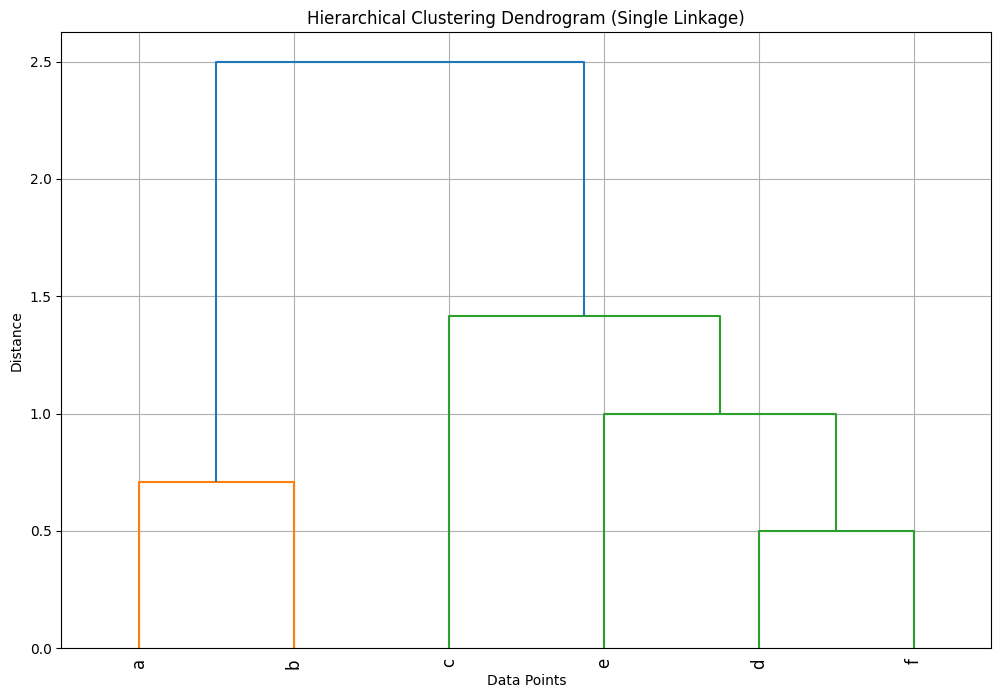

In [2]:
# 4. Hierarchical Clustering (Single Linkage)
linked_single = linkage(data, method='single')

# 5. Plot Dendrogram
plt.figure(figsize=(12, 8))
plt.title("Hierarchical Clustering Dendrogram (Single Linkage)")
dendrogram(linked_single, labels=labels, leaf_rotation=90)
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

### 2.2 Complete Linkage

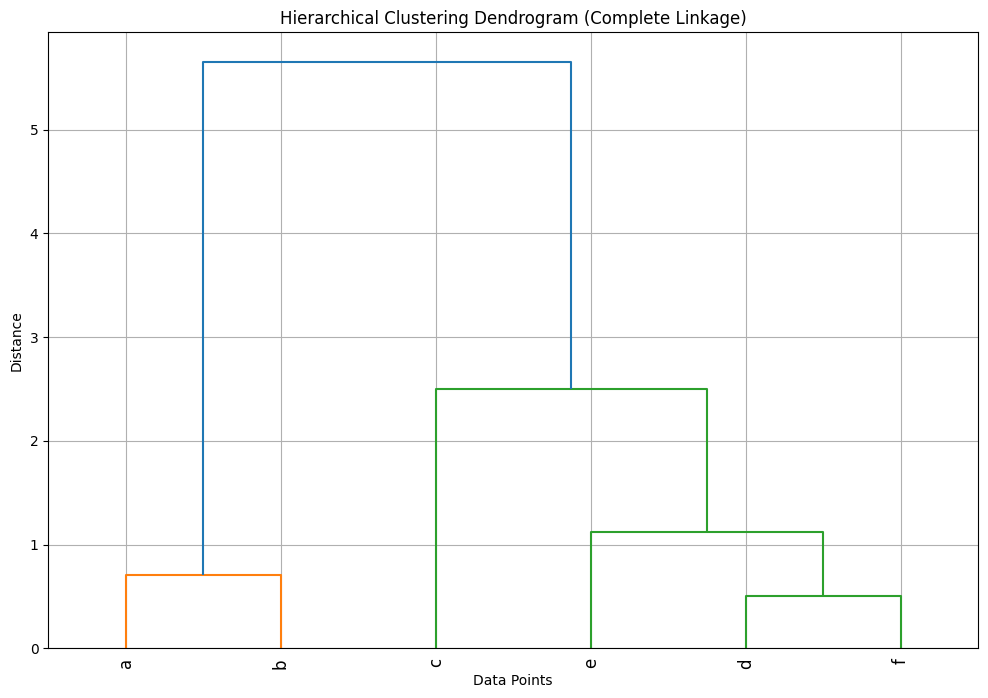

In [3]:
linked_complete = linkage(data, method='complete')

plt.figure(figsize=(12, 8))
plt.title("Hierarchical Clustering Dendrogram (Complete Linkage)")
dendrogram(linked_complete, labels=labels, leaf_rotation=90)
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

### 2.3 Average Linkage

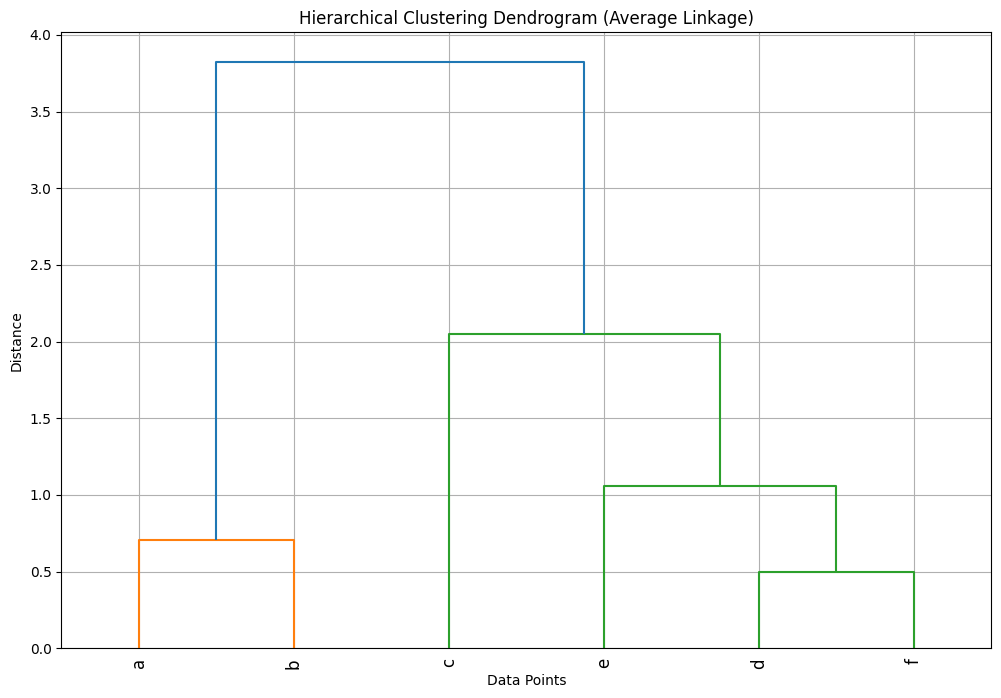

In [4]:
linked_average = linkage(data, method='average')

plt.figure(figsize=(12, 8))
plt.title("Hierarchical Clustering Dendrogram (Average Linkage)")
dendrogram(linked_average, labels=labels, leaf_rotation=90)
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

## 3. Perbandingan Ketiga Metode

Agar mudah dibandingkan, ketiga dendrogram ditampilkan berdampingan dengan skala sumbu-Y yang sama, lalu urutan penggabungan (*merge*) dari masing-masing metode ditabulasikan.

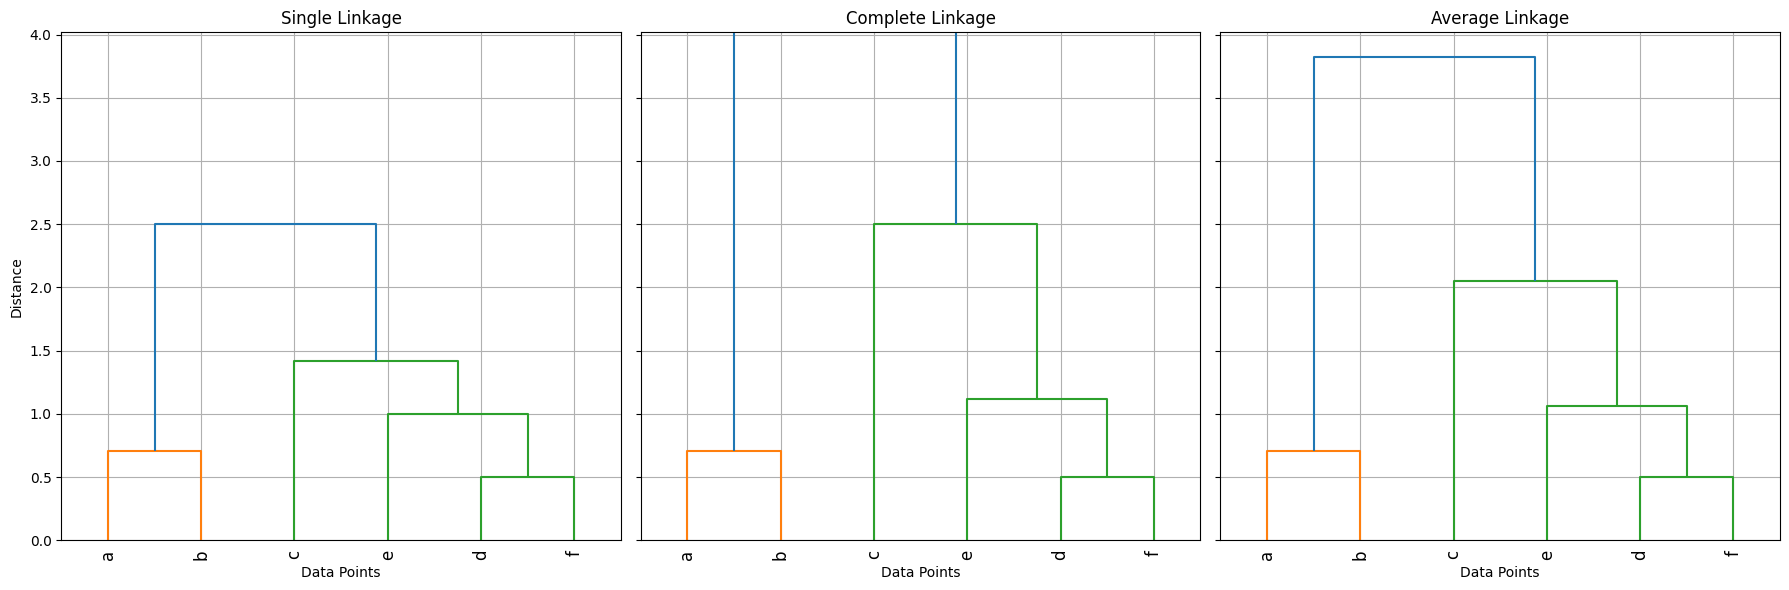

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
for ax, (name, Z) in zip(axes, [('Single', linked_single),
                                ('Complete', linked_complete),
                                ('Average', linked_average)]):
    dendrogram(Z, labels=labels, leaf_rotation=90, ax=ax)
    ax.set_title(f"{name} Linkage")
    ax.set_xlabel("Data Points")
    ax.grid(True)
axes[0].set_ylabel("Distance")
plt.tight_layout()
plt.show()

In [6]:
# Tabel urutan penggabungan klaster
names = {i: l for i, l in enumerate(labels)}
def merge_table(Z):
    nm = dict(names)
    rows = []
    for i, (c1, c2, dist, size) in enumerate(Z):
        c1, c2 = int(c1), int(c2)
        new = len(labels) + i
        nm[new] = "{" + ",".join(sorted((nm[c1] + "," + nm[c2]).replace("{","").replace("}","").split(","))) + "}"
        rows.append([i + 1, nm[c1], nm[c2], round(dist, 4), int(size)])
    return pd.DataFrame(rows, columns=["Langkah", "Klaster 1", "Klaster 2", "Jarak merge", "Ukuran"])

for name, Z in [('SINGLE', linked_single), ('COMPLETE', linked_complete), ('AVERAGE', linked_average)]:
    print(f"=== {name} LINKAGE ===")
    print(merge_table(Z).to_string(index=False))
    print()

=== SINGLE LINKAGE ===
 Langkah Klaster 1 Klaster 2  Jarak merge  Ukuran
       1         d         f       0.5000       2
       2         a         b       0.7071       2
       3         e     {d,f}       1.0000       3
       4         c   {d,e,f}       1.4142       4
       5     {a,b} {c,d,e,f}       2.5000       6

=== COMPLETE LINKAGE ===
 Langkah Klaster 1 Klaster 2  Jarak merge  Ukuran
       1         d         f       0.5000       2
       2         a         b       0.7071       2
       3         e     {d,f}       1.1180       3
       4         c   {d,e,f}       2.5000       4
       5     {a,b} {c,d,e,f}       5.6569       6

=== AVERAGE LINKAGE ===
 Langkah Klaster 1 Klaster 2  Jarak merge  Ukuran
       1         d         f       0.5000       2
       2         a         b       0.7071       2
       3         e     {d,f}       1.0590       3
       4         c   {d,e,f}       2.0501       4
       5     {a,b} {c,d,e,f}       3.8259       6



### 3.1 Tabel Ringkasan (tinggi penggabungan pada dendrogram)

| Langkah | Klaster yang digabung | Single | Complete | Average |
|:-:|---|:-:|:-:|:-:|
| 1 | d + f | 0,500 | 0,500 | 0,500 |
| 2 | a + b | 0,707 | 0,707 | 0,707 |
| 3 | e + {d,f} | 1,000 | 1,118 | 1,059 |
| 4 | c + {d,e,f} | 1,414 | 2,500 | 2,050 |
| 5 | {a,b} + {c,d,e,f} | 2,500 | 5,657 | 3,826 |

### 3.2 Pembuktian Perhitungan Manual

Langkah 1 dan 2 sama pada ketiga metode karena klaster masih berisi satu titik, sehingga jarak antar klaster sama dengan jarak antar titik.

Langkah 3: menggabungkan e dengan {d,f}:
- Single = min(d–e, f–e) = min(1,000; 1,118) = 1,000
- Complete = max(1,000; 1,118) = 1,118
- Average = (1,000 + 1,118) / 2 = 1,059

Langkah 4: menggabungkan c dengan {d,e,f}:
- Single = min(2,236; 1,414; 2,500) = 1,414
- Complete = max(2,236; 1,414; 2,500) = 2,500
- Average = (2,236 + 1,414 + 2,500) / 3 = 2,050

Langkah 5: menggabungkan {a,b} dengan {c,d,e,f} (8 pasangan jarak: a–c 5,657; a–d 3,606; a–e 4,243; a–f 3,202; b–c 4,950; b–d 2,915; b–e 3,536; b–f 2,500):
- Single = min = 2,500 (b–f)
- Complete = max = 5,657 (a–c)
- Average = jumlah / 8 = 30,609 / 8 = 3,826

## 4. Percobaan 2: Dataset Mall Customers

Pada percobaan kedua, dataset Mall Customers digunakan untuk mengelompokkan pelanggan berdasarkan dua fitur, yaitu **Annual Income** dan **Spending Score**, dengan *complete linkage* dan jarak Euclidean sesuai modul.

In [ ]:
import pandas as pd
import os

path = "/content/Mall_Customers.csv"
if not os.path.exists(path):
    path = "Mall_Customers.csv"
df = pd.read_csv(path)
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [8]:
x = df.iloc[:, [3, 4]].values   # Annual Income & Spending Score
x[:5]

array([[15, 39],
       [15, 81],
       [16,  6],
       [16, 77],
       [17, 40]])

Standarisasi data. Kedua fitur memiliki skala berbeda (income 15–137, score 1–99), sehingga distandarisasi dengan StandardScaler agar tidak ada fitur yang mendominasi perhitungan jarak.

In [9]:
from sklearn.preprocessing import StandardScaler

data_scaler = StandardScaler()
scaled_data = data_scaler.fit_transform(x)
scaled_data.shape

(200, 2)

In [10]:
from scipy.cluster.hierarchy import linkage, dendrogram

clustering = linkage(scaled_data, method="complete", metric="euclidean")

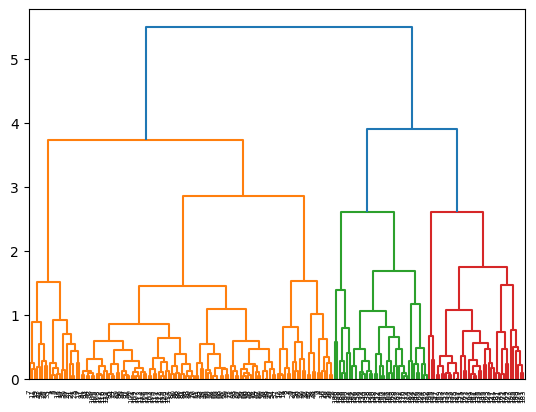

In [11]:
import matplotlib.pyplot as plt

dendrogram(clustering)
plt.show()

Interpretasi dendrogram: Dendrogram membagi data pelanggan menjadi tiga kelompok utama (oranye, hijau, merah). Untuk memastikan, dendrogram dipotong menjadi 3 klaster lalu profil tiap klaster dihitung.

        Annual Income (k$)             Spending Score (1-100)            
                     count  mean   std                  count  mean   std
Cluster                                                                  
1                      123  44.2  16.0                    123  49.8  19.7
2                       38  87.0  16.3                     38  18.6  10.9
3                       39  86.5  16.3                     39  82.1   9.4


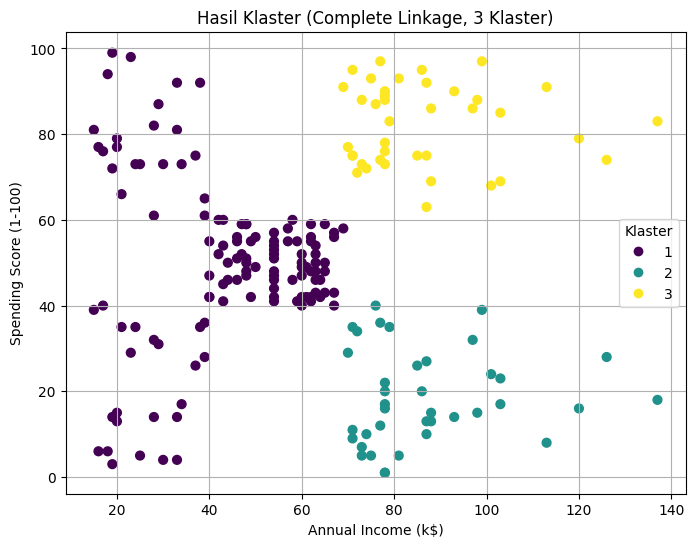

In [12]:
from scipy.cluster.hierarchy import fcluster

df['Cluster'] = fcluster(clustering, t=3, criterion='maxclust')

profil = df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].agg(['count', 'mean', 'std']).round(1)
print(profil)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
                      c=df['Cluster'], cmap='viridis', s=40)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Hasil Klaster (Complete Linkage, 3 Klaster)")
plt.legend(*scatter.legend_elements(), title="Klaster")
plt.grid(True)
plt.show()

Profil klaster hasil pemotongan 3 klaster:

| Klaster | Jumlah | Rata-rata Income (k$) | Rata-rata Spending Score | Interpretasi |
|:-:|:-:|:-:|:-:|---|
| 1 | 123 | 44,2 | 49,8 | Pelanggan dengan income dan pengeluaran sedang (kelompok terbesar) |
| 2 | 38 | 87,0 | 18,6 | Pelanggan berpenghasilan tinggi tetapi pengeluaran rendah |
| 3 | 39 | 86,5 | 82,1 | Pelanggan berpenghasilan tinggi dan pengeluaran tinggi |

Manfaat bisnis: Segmentasi ini sejalan dengan contoh pada modul (pengeluaran rendah, sedang, dan tinggi). Klaster 3 merupakan target utama program loyalitas/penawaran premium, klaster 2 berpotensi ditingkatkan pengeluarannya melalui promosi yang tepat, dan klaster 1 cocok untuk penawaran umum/diskon rutin.

Catatan: Klaster 1 paling heterogen (simpangan baku Spending Score paling besar) karena pelanggan berpenghasilan rendah dengan skor sangat tinggi maupun sangat rendah ikut tergabung di dalamnya pada pemotongan 3 klaster. Jika ingin segmentasi lebih halus, dendrogram dapat dipotong pada jumlah klaster yang lebih banyak (misalnya 5).

## 5. Analisis dan Kesimpulan

Hasil perbandingan:

1. Struktur klaster (topologi) sama. Pada ketiga dendrogram, urutan penggabungannya identik: (d,f) → (a,b) → e bergabung ke (d,f) → c bergabung ke (d,e,f) → terakhir (a,b) bergabung dengan (c,d,e,f). Jika dipotong menjadi dua klaster, hasilnya konsisten yaitu {a,b} dan {c,d,e,f}. Hal ini terjadi karena dataset sederhana dan kedua kelompok terpisah cukup jelas.

2. Perbedaan terletak pada tinggi penggabungan (jarak). Single linkage menghasilkan tinggi paling rendah (tinggi akhir 2,5), complete linkage paling tinggi (5,657), dan average linkage berada di tengah (3,826). Ini sesuai definisinya: min ≤ rata-rata ≤ max.

3. Single linkage cenderung membentuk rantai (chaining effect): klaster digabung begitu ada satu titik yang berdekatan, sehingga dendrogram tampak "bertangga" dan rendah. Metode ini sensitif terhadap noise dan outlier.

4. Complete linkage mempertimbangkan titik terjauh sehingga menghasilkan klaster yang lebih padat/kompak, dengan tinggi penggabungan terakhir yang paling besar (dipengaruhi pasangan a–c yang berjarak 5,657). Metode ini lebih sensitif terhadap *outlier* yang berjauhan.

5. Average linkage merupakan kompromi antara keduanya: tidak sebertangga single dan tidak seekstrem complete.

Kesimpulan: Pada dataset sederhana ini, pilihan metode linkage tidak mengubah pengelompokan akhir, tetapi mengubah skala jarak penggabungan pada dendrogram. Pada percobaan 2 (Mall Customers), complete linkage menghasilkan tiga segmen pelanggan yang dapat diinterpretasikan secara bisnis (pengeluaran sedang, tinggi-income/rendah-spending, dan tinggi-income/tinggi-spending).